In [10]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
alincijov_self_driving_cars_path = kagglehub.dataset_download('alincijov/self-driving-cars')

print('Data source import complete.')


Using Colab cache for faster access to the 'self-driving-cars' dataset.
Data source import complete.


In [11]:
import numpy as np
import pandas as pd
import cv2

from sklearn.utils import shuffle
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt

import warnings

warnings.simplefilter('ignore')

In [12]:
df = pd.read_csv('/kaggle/input/self-driving-cars/labels_train.csv')
df = shuffle(df)
df.head()

,frame,xmin,xmax,ymin,ymax,class_id
84339,1479501790198564366.jpg,334,370,128,153,1
64603,1479498672984030191.jpg,351,478,114,215,1
10053,1478020968722256855.jpg,206,225,136,155,1
46169,1478897559070002803.jpg,62,133,141,191,1
19136,1478732217726925274.jpg,105,114,71,91,5


In [13]:
from sklearn.model_selection import train_test_split

# Split gambar menjadi train/test secara acak, dengan seed tetap
train_images, test_images = train_test_split(df, test_size=0.2, random_state=42)

train_images.head()

,frame,xmin,xmax,ymin,ymax,class_id
38236,1478896936364290466.jpg,55,92,155,177,1
57412,1478898369728707394.jpg,316,332,83,120,5
35343,1478896723272322315.jpg,83,327,116,288,1
129173,1479505937980201660.jpg,228,236,140,156,3
85122,1479501859203598746.jpg,249,258,143,152,1


In [14]:
classes = df.class_id.unique()
print(classes)

[1 5 3 2 4]


In [15]:
labels = { 1:'car', 2:'truck', 3:'person', 4:'bicycle', 5:'traffic light'}

In [16]:
boxes = {}
images = {}

base_path = '../input/self-driving-cars/images/'

for class_id in classes:
    first_row = df[df['class_id'] == class_id].iloc[0]

    images[class_id] = cv2.imread(base_path + first_row['frame'])
    boxes[class_id] = [first_row['xmin'],first_row['xmax'],first_row['ymin'],first_row['ymax']]

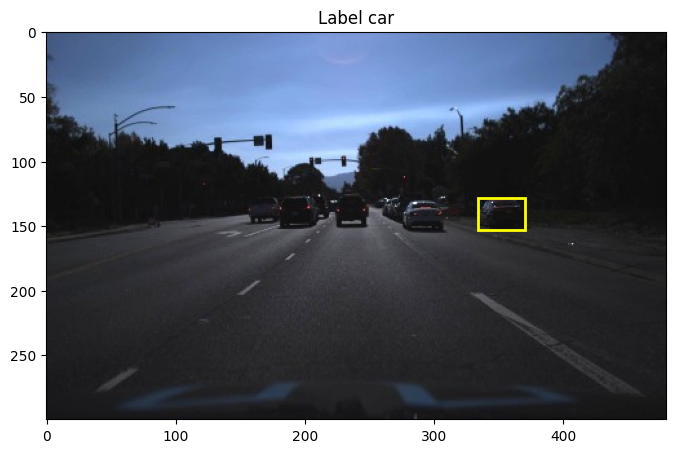

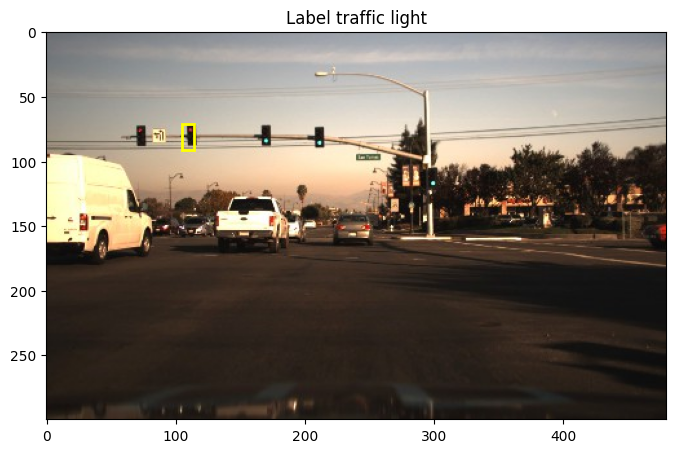

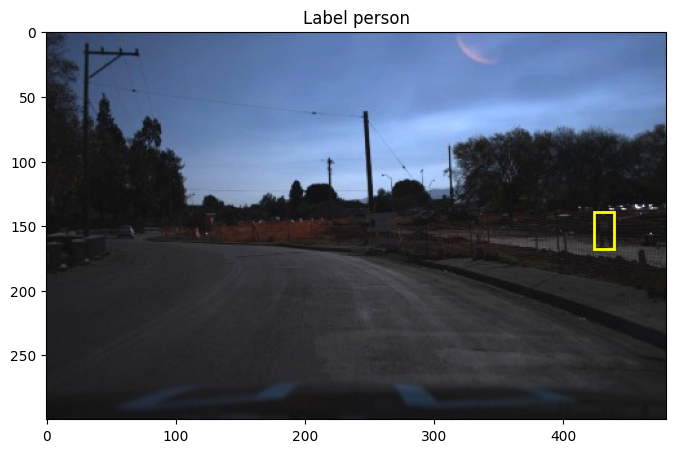

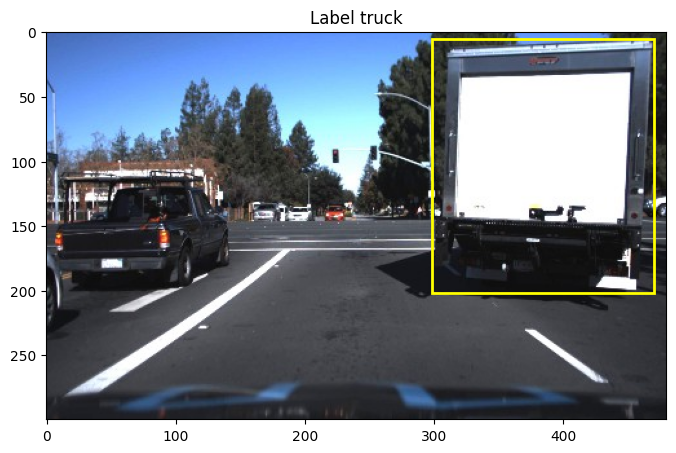

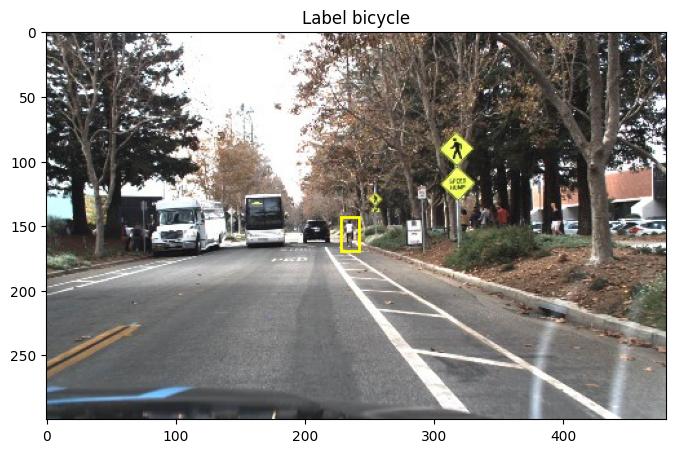

In [17]:
import os

# Correcting the base_path to load images from the kagglehub dataset
# The variable 'alincijov_self_driving_cars_path' is available from the first cell.
base_path = alincijov_self_driving_cars_path + '/images/'

# Re-populating images and boxes dictionaries with the corrected path
# This ensures the images are loaded correctly for the current cell's execution.
boxes = {}
images = {}

# 'classes' and 'df' are assumed to be available from previous cells.
for class_id in classes:
    first_row = df[df['class_id'] == class_id].iloc[0]
    image_path = os.path.join(base_path, first_row['frame'])
    images[class_id] = cv2.imread(image_path) # Reload images with correct path

    # Check for successful image load and print a warning if not
    if images[class_id] is None:
        print(f"Warning: Failed to load image from path: {image_path} for class {class_id}")

    # Ensure boxes are also correctly populated here as they might be used together
    boxes[class_id] = [first_row['xmin'],first_row['xmax'],first_row['ymin'],first_row['ymax']]


for i in classes:
    # Skip plotting if the image for this class was not successfully loaded
    if images[i] is None:
        print(f"Skipping display for class {i} ({labels.get(i, 'Unknown Class')}) as image failed to load.")
        continue

    xmin, xmax, ymin, ymax = boxes[i][0], boxes[i][1], boxes[i][2], boxes[i][3]

    plt.figure(figsize=(8, 10))
    plt.title("Label " + labels[i])
    # Convert BGR to RGB for correct display with matplotlib
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.gca().add_patch(plt.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, color='yellow', fill=False, linewidth=2))

    plt.show()

In [18]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.0 MB/s eta 0:00:00


In [19]:
from ultralytics import YOLO
import PIL
from PIL import Image
from IPython.display import display
import os
import pathlib

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [20]:
model = YOLO("yolov8m.pt")

In [21]:
results=model.predict(source="/kaggle/input/self-driving-cars/images/1478019956680248165.jpg",
              save=True, conf=0.2,iou=0.5)


image 1/1 /kaggle/input/self-driving-cars/images/1478019956680248165.jpg: 416x640 1 car, 1 truck, 2411.3ms
Speed: 9.4ms preprocess, 2411.3ms inference, 37.1ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/detect/predict


In [22]:
result = results[0]
box = result.boxes[0]

In [23]:
for result in results:
    boxes = result.boxes  # Boxes object for bbox outputs
    masks = result.masks  # Masks object for segmentation masks outputs
    probs = result.probs

In [24]:
cords = box.xyxy[0].tolist()
class_id = box.cls[0].item()
conf = box.conf[0].item()
print("Object type:", class_id)
print("Coordinates:", cords)
print("Probability:", conf)

Object type: 2.0
Coordinates: [124.69143676757812, 142.6882781982422, 148.7809295654297, 162.10047912597656]
Probability: 0.7161701321601868


In [25]:
for box in result.boxes:
    class_id = result.names[box.cls[0].item()]
    cords = box.xyxy[0].tolist()
    cords = [round(x) for x in cords]
    conf = round(box.conf[0].item(), 2)
    print("Object type:", class_id)
    print("Coordinates:", cords)
    print("Probability:", conf)
    print("---")

Object type: car
Coordinates: [125, 143, 149, 162]
Probability: 0.72
---
Object type: truck
Coordinates: [141, 139, 157, 154]
Probability: 0.31
---


In [26]:
results1 = model.predict(source="/kaggle/input/self-driving-cars/images/1478019954685370994.jpg",
              save=True, conf=0.2,iou=0.5)

Results = results1[0]


image 1/1 /kaggle/input/self-driving-cars/images/1478019954685370994.jpg: 416x640 4 cars, 1 truck, 2775.5ms
Speed: 7.1ms preprocess, 2775.5ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/detect/predict


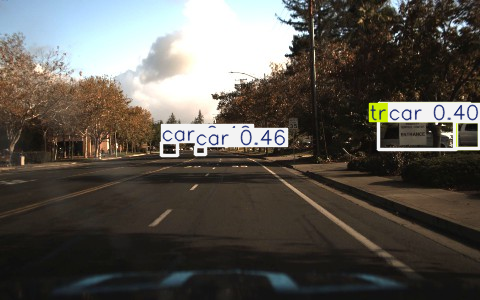

In [27]:
# Plotting results
plot = results1[0].plot()

plot = cv2.cvtColor(plot, cv2.COLOR_BGR2RGB)
display(Image.fromarray(plot))